In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
import openml

In [2]:

dataset = openml.datasets.get_dataset(46858)

X, y, categorical_indicator, attribute_names = dataset.get_data(
    dataset_format="dataframe",
    target="isFraud"
)


In [3]:
df = X.copy()
df["isFraud"] = y


In [4]:
identifier_cols = ["TransactionDT","TransactionAmt", "isFraud"]
cat_features = ['ProductCD','card4','card6', 'P_emaildomain', 'R_emaildomain',
                'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'DeviceType', 'DeviceInfo', 'id_12', 'id_15',
                'id_16','id_23','id_27','id_28','id_29','id_30','id_31',
                'id_33','id_34','id_35','id_36','id_37','id_38']


numerical_features = [ x for x in df.columns.values if x not in cat_features + identifier_cols ]

features = numerical_features + cat_features

print('Categorical features :', len(cat_features))
print('Numerical features : ',len(numerical_features))

Categorical features : 31
Numerical features :  422


In [5]:
null_percent = pd.DataFrame((df.isnull().sum()/len(df))*100,columns = ['percentage'])

In [6]:
null_percent.sort_values(by='percentage',ascending = False).head(15)

,percentage
id-05,100.0
id-24,100.0
id-06,100.0
id-08,100.0
id-09,100.0
id-10,100.0
id-11,100.0
id-07,100.0
id-14,100.0
id-17,100.0


In [7]:
df = df.dropna(axis=1, how="all")

In [8]:
null_percent = pd.DataFrame((df.isnull().sum()/len(df))*100,columns = ['percentage'])

In [9]:
null_percent.sort_values(by='percentage',ascending = False).head(15)

,percentage
id_24,99.196159
id_25,99.130965
id_07,99.127070
id_08,99.127070
id_21,99.126393
id_26,99.125715
id_22,99.124699
id_27,99.124699
id_23,99.124699
dist2,93.628374


##### Columns id_07, id_08, id_21 - id_27 have percentage of null values more than 99%

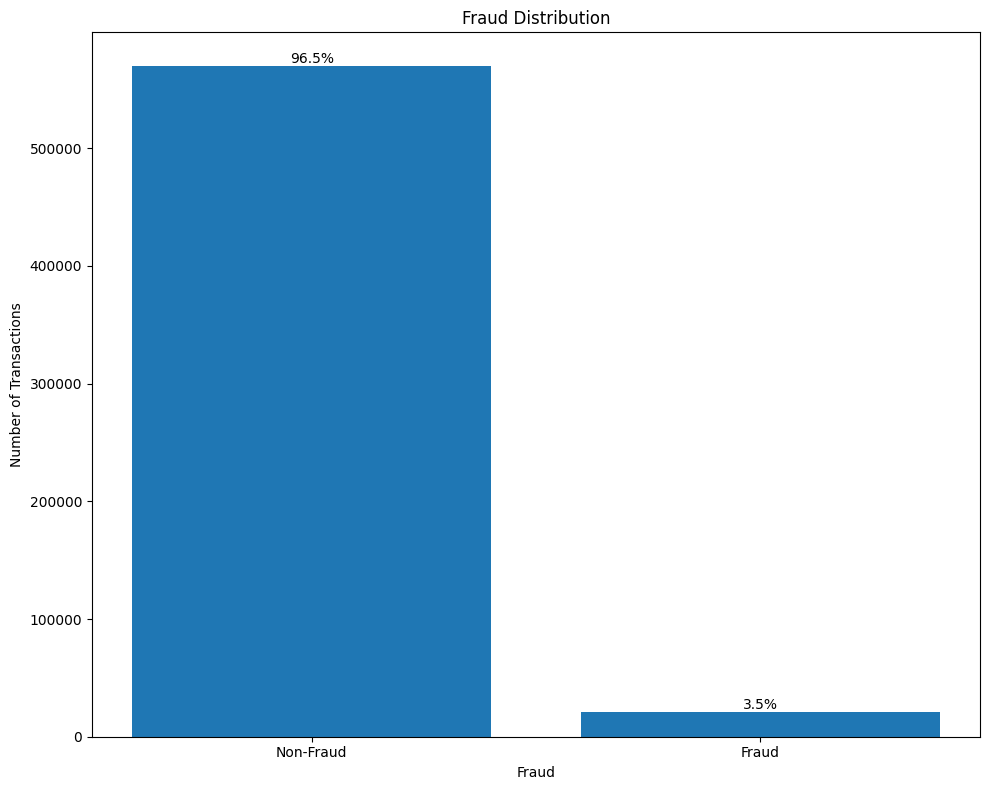

In [10]:
%matplotlib inline

counts = df["isFraud"].value_counts().sort_index()
percentages = df["isFraud"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.bar(
    ["Non-Fraud", "Fraud"],
    counts
)

ax.set_title("Fraud Distribution")
ax.set_xlabel("Fraud")
ax.set_ylabel("Number of Transactions")

# Add percentage labels
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

- The dataset is **highly imbalanced**, so accuracy alone is not sufficient for evaluating fraud detection.
- Further analysis will focus on **fraud rate, recall, precision, and false positives**.

## TransactionAmt

In [11]:
df["TransactionAmt"].describe()


count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

In [12]:
df["TransactionAmt"].isnull().sum()

0

,transactions,fraud_cases,fraud_rate
amount_bin,,,
< €25,50829,3150.0,6.197250
€25–50,153695,4683.0,3.046944
€50–100,164095,4788.0,2.917822
€100–200,128041,3899.0,3.045118
€200–500,71001,3135.0,4.415431
"€500–1,000",15612,829.0,5.310018
"> €1,000",7267,179.0,2.463190


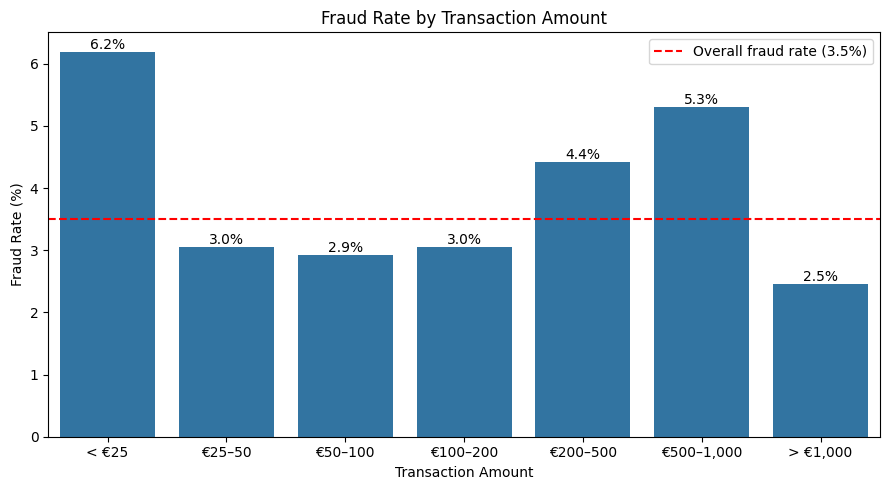

In [13]:
# 1. Create predefined transaction amount ranges
bins = [0, 25, 50, 100, 200, 500, 1000, float("inf")]
labels = [
    "< €25",
    "€25–50",
    "€50–100",
    "€100–200",
    "€200–500",
    "€500–1,000",
    "> €1,000"
]

df["amount_bin"] = pd.cut(
    df["TransactionAmt"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df["isFraud_num"] = pd.to_numeric(df["isFraud"].astype(str), errors="coerce")
# 2. Calculate transaction volume and fraud rate
amount_fraud = (
    df.groupby("amount_bin", observed=True)
      .agg(
          transactions=("isFraud_num", "count"),
          fraud_cases=("isFraud_num", "sum"),
          fraud_rate=("isFraud_num", "mean")
      )
)

amount_fraud["fraud_rate"] *= 100

# 3. Display results
display(amount_fraud)

# 4. Plot fraud rate
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=amount_fraud.reset_index(),
    x="amount_bin",
    y="fraud_rate"
)

# Overall fraud rate
overall_fraud_rate = df["isFraud_num"].mean() * 100

ax.axhline(
    overall_fraud_rate,
    color= "red",
    linestyle="--",
    label=f"Overall fraud rate ({overall_fraud_rate:.1f}%)"
)

ax.set_xlabel("Transaction Amount")
ax.set_ylabel("Fraud Rate (%)")
ax.set_title("Fraud Rate by Transaction Amount")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

ax.legend()

plt.tight_layout()
plt.show()

- Transaction amount shows a non-linear relationship with fraud. Transactions below €25 have the highest fraud rate at 6.2%, while transactions €500 - €1,000 have a fraud rate of 5.3% with an overall rate 3.5%.

- However, the differences are not strong enough to use transaction amount alone as a fraud rule. Therefore, the next step is to investigate other transaction characteristics that may explain these differences.

## ProductCD

In [14]:
product_summary = (
    df.groupby("ProductCD", observed=True)["isFraud_num"]
      .agg(total="count", fraud="sum")
)

product_summary["not_fraud"] = (
    product_summary["total"] - product_summary["fraud"]
)

product_summary["distribution"] = (
    product_summary["total"] / product_summary["total"].sum() * 100
)

product_summary

,total,fraud,not_fraud,distribution
ProductCD,,,,
C,68519,8008.0,60511.0,11.602770
H,33024,1574.0,31450.0,5.592170
R,37699,1426.0,36273.0,6.383818
S,11628,686.0,10942.0,1.969045
W,439670,8969.0,430701.0,74.452196


In [15]:

def plot_fraud_summary(df, column):

    summary = (
        df.groupby(column, observed=True)["isFraud_num"]
          .agg(
              transactions="count",
              fraud="sum"
          )
    )

    summary["not_fraud"] = (
        summary["transactions"] - summary["fraud"]
    )

    plot_df = summary.reset_index()

    ax = plot_df.set_index(column)[["not_fraud", "fraud"]].plot(
        kind="bar",
        figsize=(12, 10)
    )

    ax.set_xlabel(column)
    ax.set_ylabel("Number of Transactions")
    ax.set_title(f"Fraud vs Not Fraud by {column}")

    total_transactions = summary["transactions"].sum()

    for i, row in plot_df.iterrows():

        not_fraud_pct = row["not_fraud"] / total_transactions * 100
        fraud_pct = row["fraud"] / total_transactions * 100

        ax.text(
            i - 0.15,
            row["not_fraud"] * 1.01,
            f'{row["not_fraud"]:,}\n({not_fraud_pct:.1f}%)',
            ha="center"
        )

        ax.text(
            i + 0.15,
            row["fraud"] * 1.01,
            f'{row["fraud"]:,}\n({fraud_pct:.1f}%)',
            ha="center"
        )

    plt.tight_layout()
    plt.show()

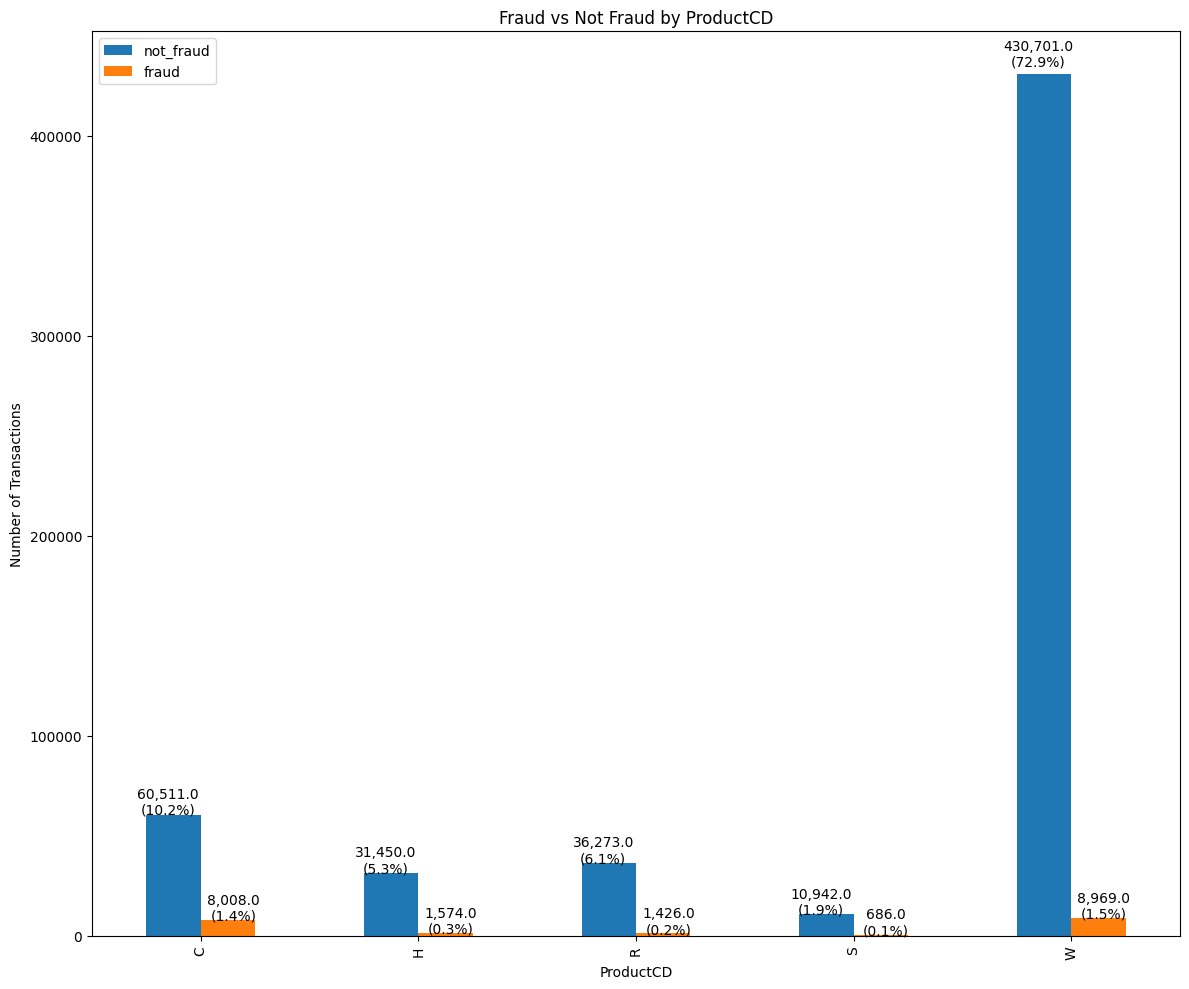

In [16]:
plot_fraud_summary(df, "ProductCD")



- ProductCD W is mostly being used with the highest percentage of transaction (~73%) with fraud rate of 1.5%
- Despite having much smaller amount of transaction, ProductCD C has nearly the same fraud rate of ProductCD W.

## Card 1 - 6

In [17]:
card = [crd for crd in df.columns if "card" in crd]



In [18]:
df[card].head()

,card1,card2,card3,card4,card5,card6
0,13926,NaN,150.0,discover,142.0,credit
1,2755,404.0,150.0,mastercard,102.0,credit
2,4663,490.0,150.0,visa,166.0,debit
3,18132,567.0,150.0,mastercard,117.0,debit
4,4497,514.0,150.0,mastercard,102.0,credit


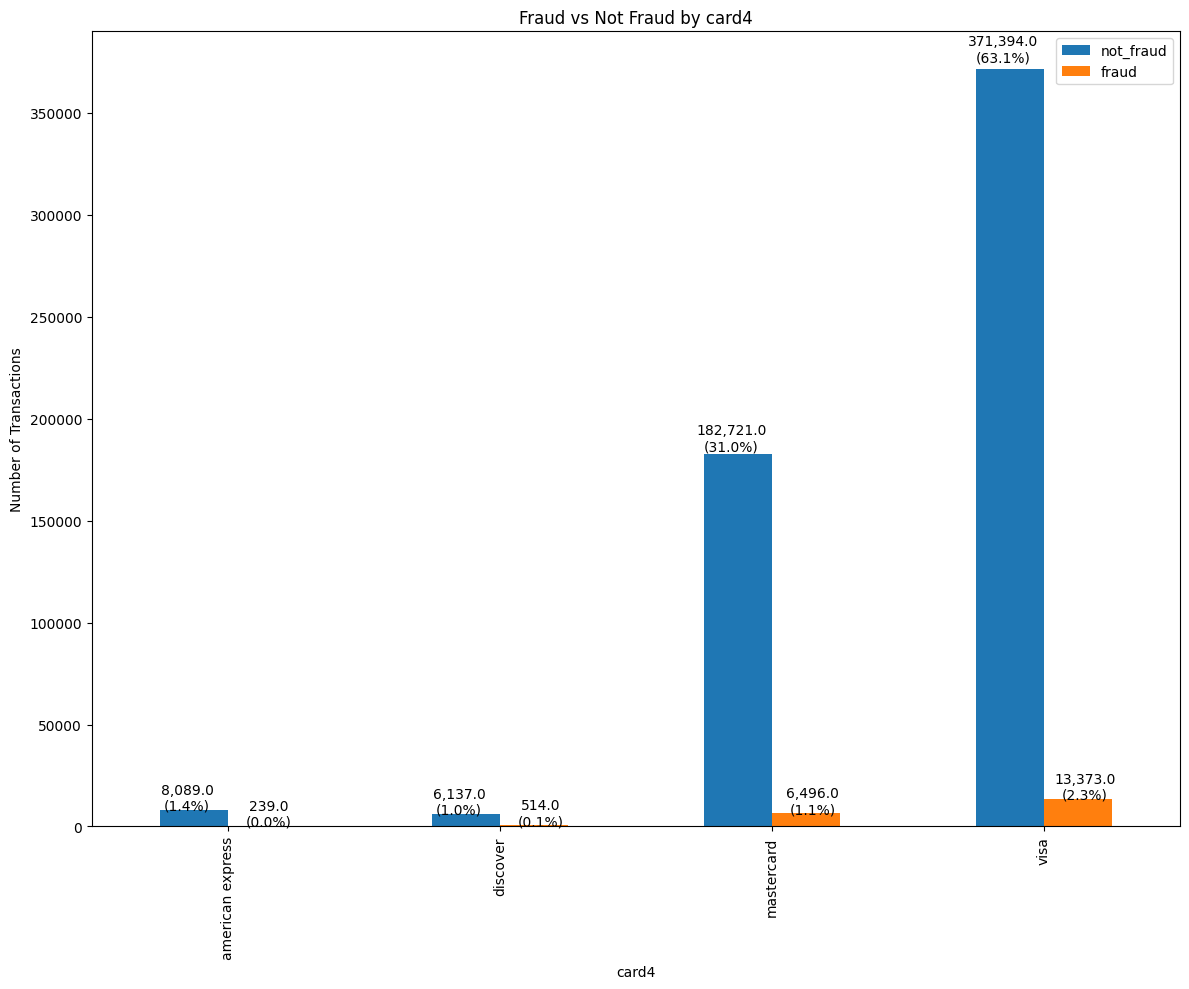

In [19]:
plot_fraud_summary(df, "card4")

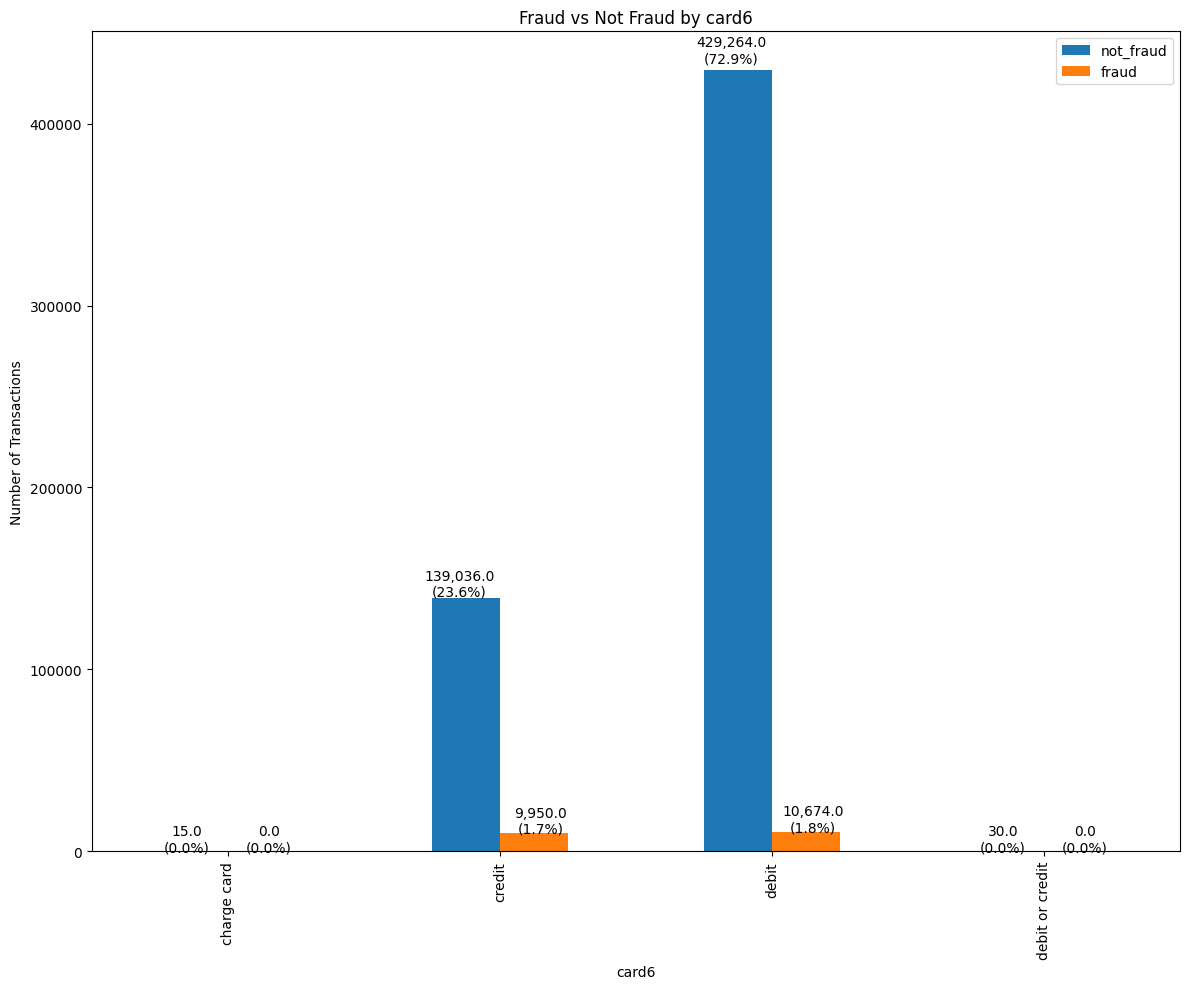

In [20]:
plot_fraud_summary(df, "card6")

- Most transactions are from debit and visa card with the low fraud rate
- On the other hand, credit and mastercard have lower amount of transaction but the same fraud rate as debit and visa cards 

## Recipient and Provider email domain

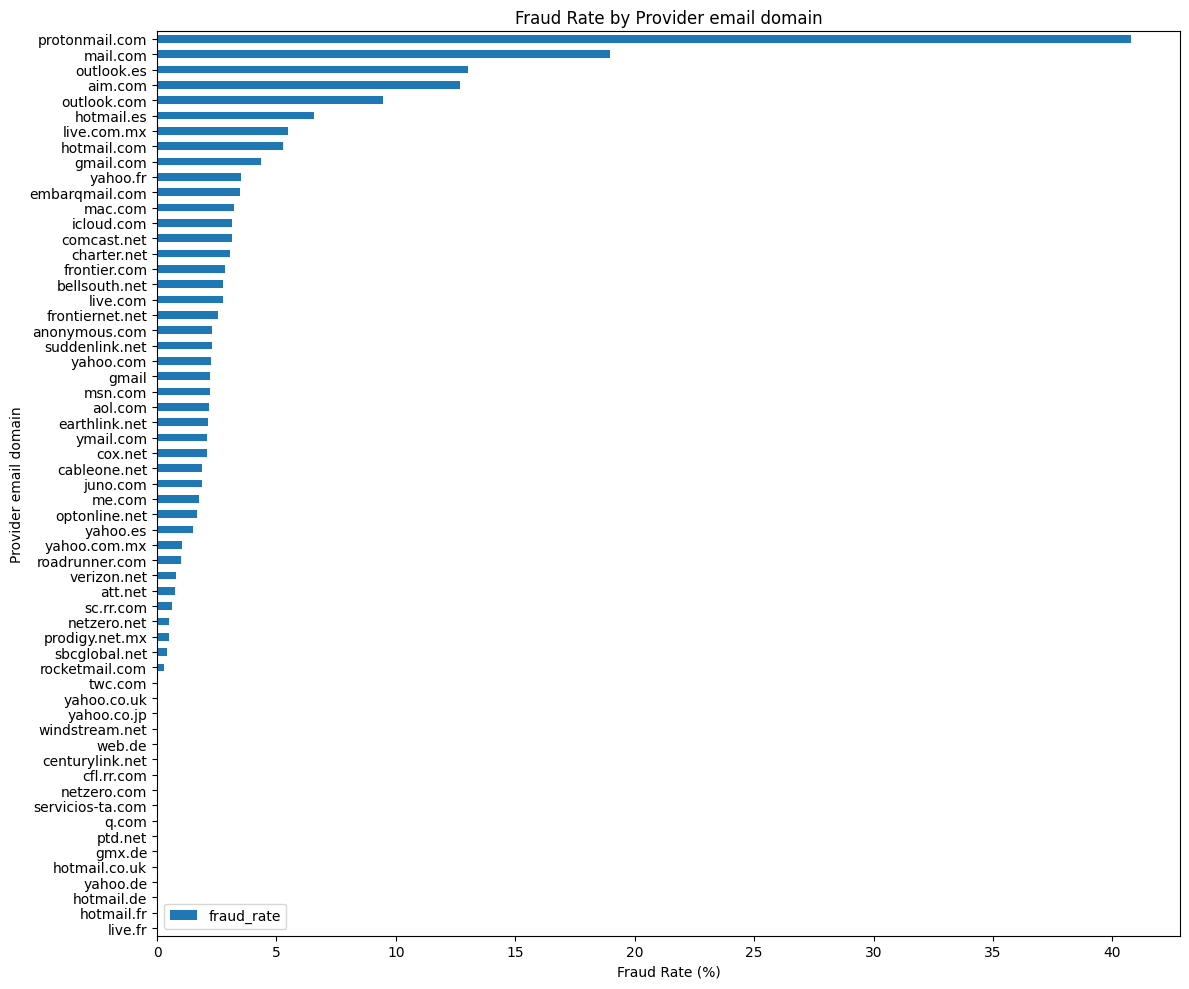

In [21]:
summary = (
    df.groupby("P_emaildomain", observed=True)["isFraud_num"]
      .agg(
          transactions="count",
          fraud="sum"
      )
)

summary["fraud_rate"] = (
    summary["fraud"] / summary["transactions"] * 100
)

summary = summary.sort_values("fraud_rate")

summary.plot(
    y="fraud_rate",
    kind="barh",
    figsize=(12, 10)
)

plt.xlabel("Fraud Rate (%)")
plt.ylabel("Provider email domain")
plt.title("Fraud Rate by Provider email domain")

plt.tight_layout()
plt.show()

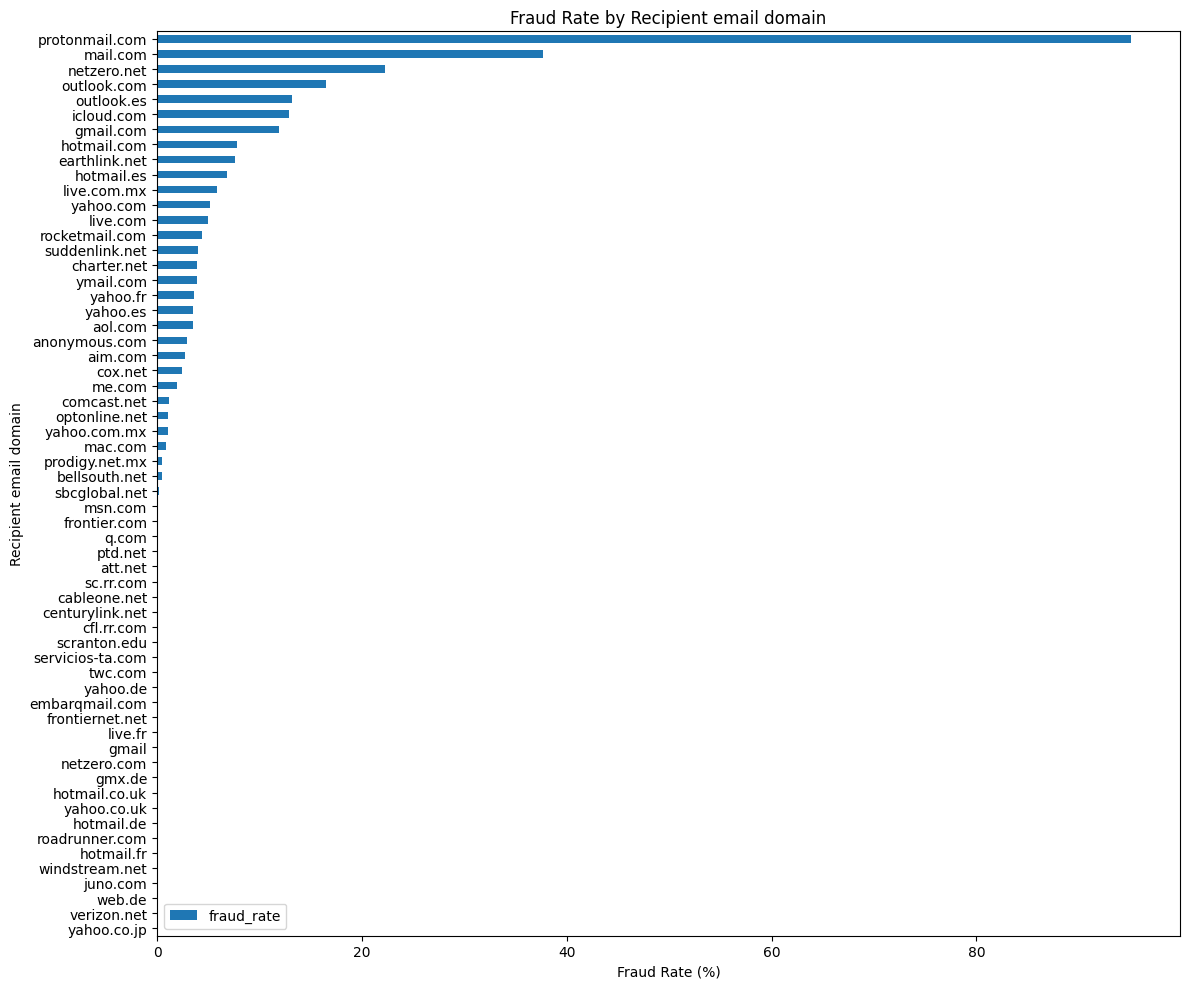

In [22]:
summary = (
    df.groupby("R_emaildomain", observed=True)["isFraud_num"]
      .agg(
          transactions="count",
          fraud="sum"
      )
)

summary["fraud_rate"] = (
    summary["fraud"] / summary["transactions"] * 100
)

summary = summary.sort_values("fraud_rate")

summary.plot(
    y="fraud_rate",
    kind="barh",
    figsize=(12, 10)
)

plt.xlabel("Fraud Rate (%)")
plt.ylabel("Recipient email domain")
plt.title("Fraud Rate by Recipient email domain")

plt.tight_layout()
plt.show()

- Most fraud events appear to involve **protonmail.com** from both the provider and recipient email domain.


## Device type and information

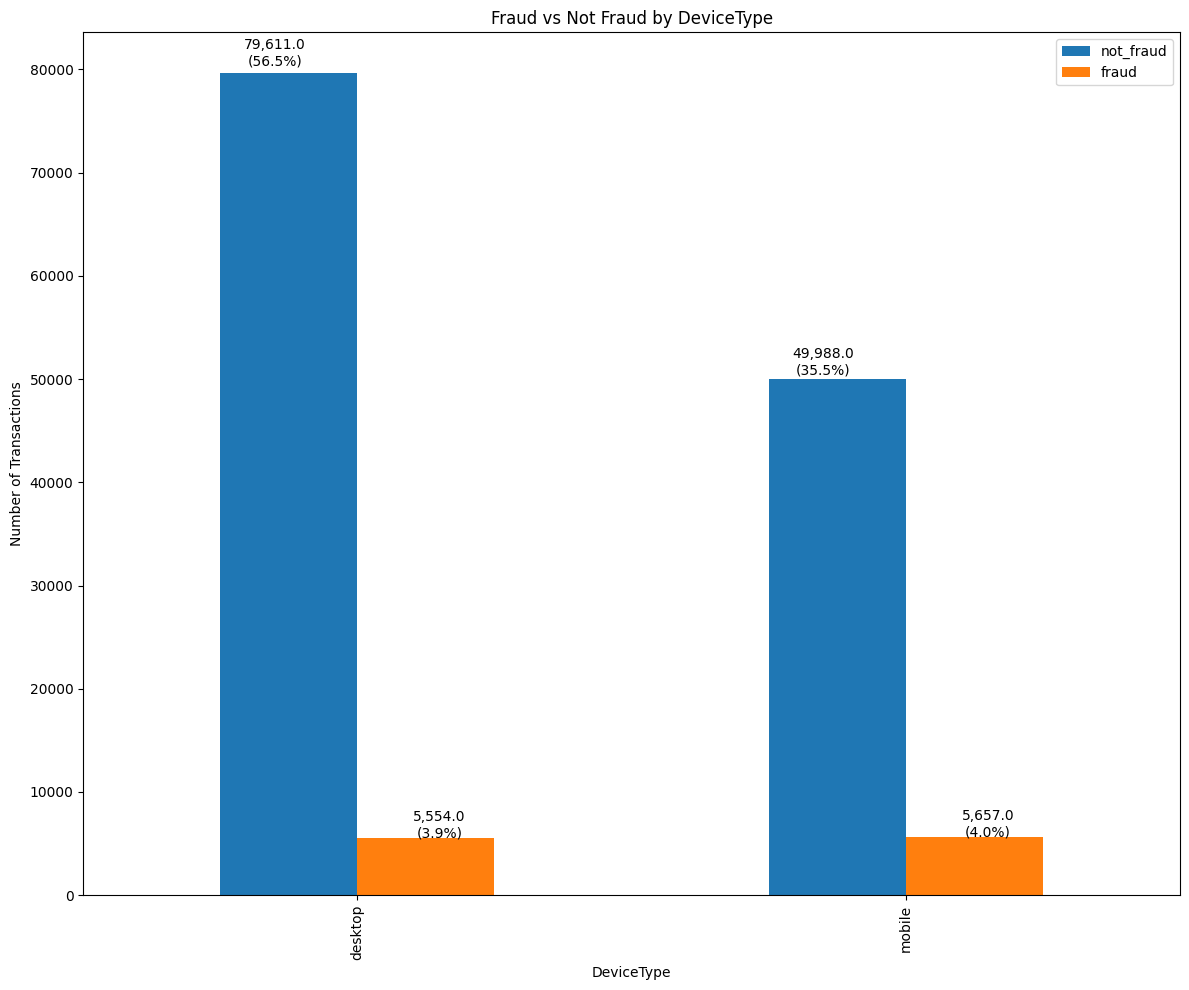

In [23]:
plot_fraud_summary(df, "DeviceType")

- Mobile transactions show a higher number of fraud cases than desktop transactions.


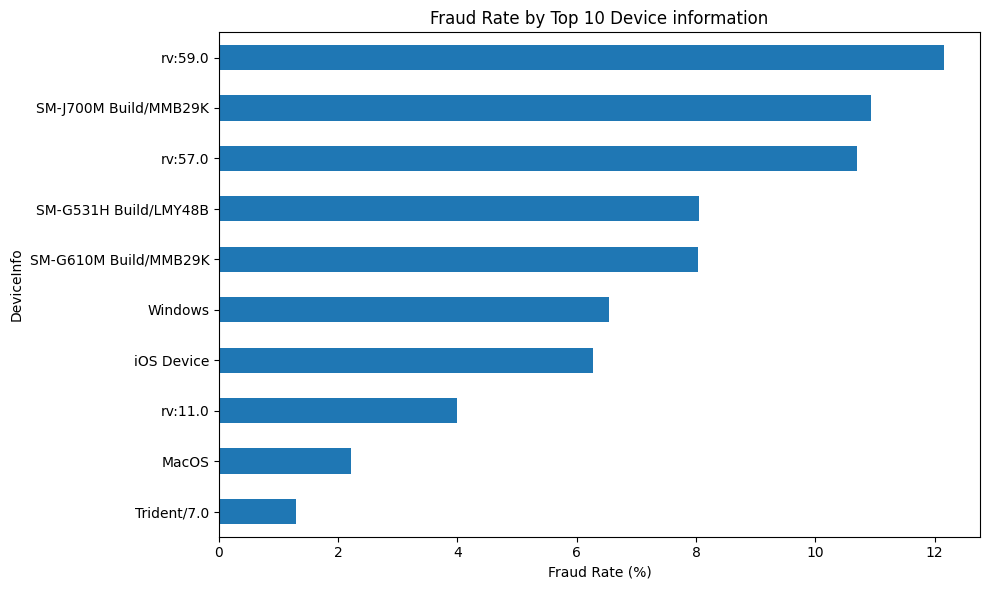

In [24]:
device_summary = (
    df.groupby("DeviceInfo", observed=True)["isFraud_num"]
      .agg(
          transactions="count",
          fraud="sum"
      )
)

device_summary["fraud_rate"] = (
    device_summary["fraud"] /
    device_summary["transactions"] * 100
)

device_summary = (
    device_summary
    .sort_values("transactions", ascending=False)
    .head(10)
    .sort_values("fraud_rate")
)

device_summary["fraud_rate"].plot(
    kind="barh",
    figsize=(10, 6)
)

plt.xlabel("Fraud Rate (%)")
plt.ylabel("DeviceInfo")
plt.title("Fraud Rate by Top 10 Device information")
plt.tight_layout()
plt.show()


## Transactions throughout the week

In [25]:
df_copy= df.copy()

df_copy["dayOfWeek"] = (
    df_copy["TransactionDT"] // 86400 - 1
) % 7

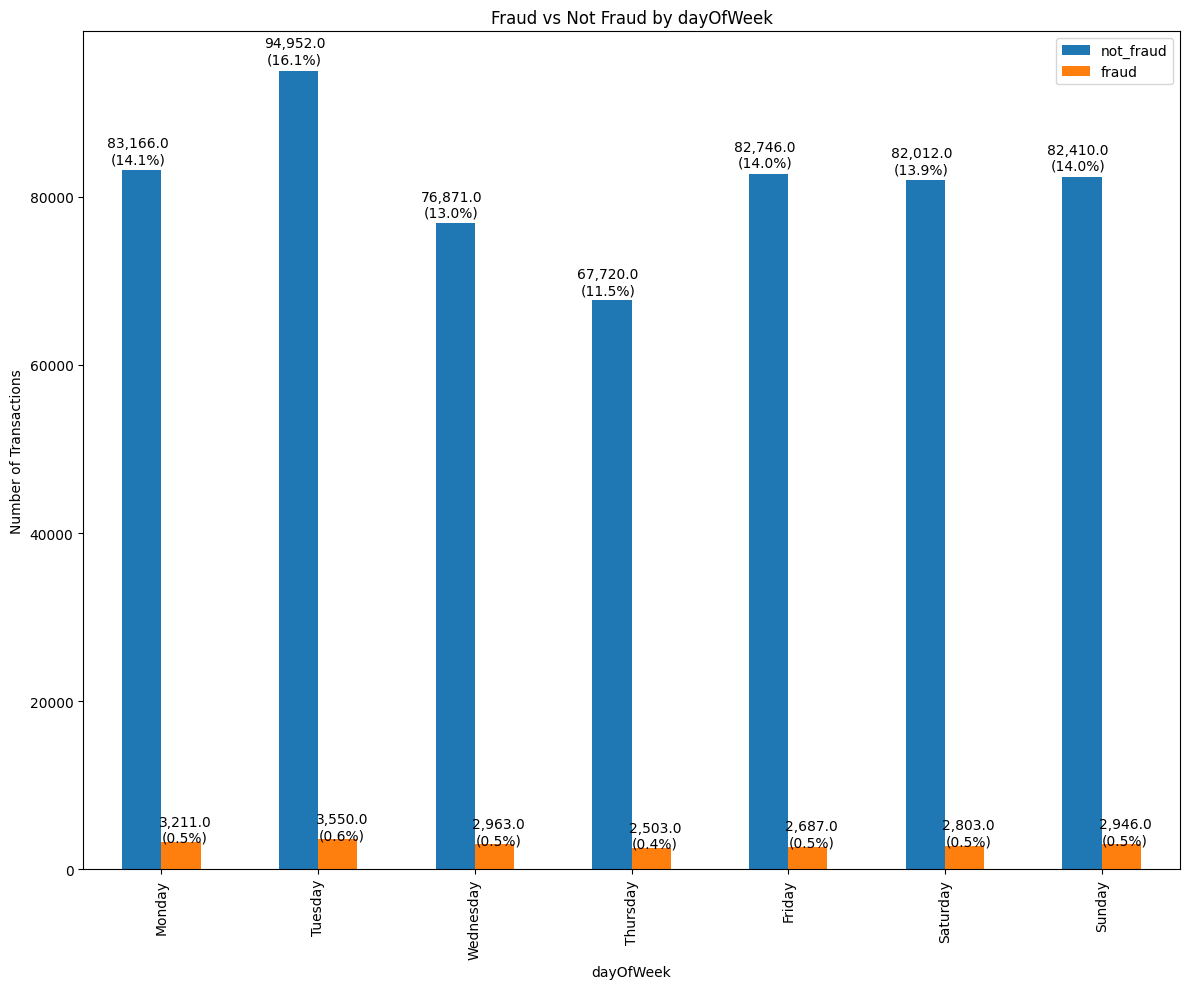

In [27]:
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

df_copy["dayOfWeek"] = (df_copy["TransactionDT"] // 86400) % 7
df_copy["dayOfWeek"] = df_copy["dayOfWeek"].map(day_names)

df_copy["dayOfWeek"] = pd.Categorical(
    df_copy["dayOfWeek"],
    categories=list(day_names.values()),
    ordered=True
)

plot_fraud_summary(df_copy, "dayOfWeek")

- There are no significant differences in fraud rates across the days of the week.